In [ ]:
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import get_train_test_data, train_mlp, train_baseline_model
from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.config import Config
from ml_baselines.data import read_agage, read_intem
from ml_baselines.modelling.plot import BaselineLabelledObservations

ImportError: cannot import name 'plot_confusion_matrix' from 'ml_baselines.modelling.plot' (/user/work/ef17148/ml-baselines/ml_baselines/modelling/plot.py)

In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
cfg = Config()
site = "MHD"

In [ ]:
params_dict = {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 50, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'adam'}
model, X, y = train_baseline_model(site, model_type="mlp", model_params=params_dict, return_scores=False, verbose=True)

In [4]:
model, x, y = train_baseline_model("MHD", model_type="random_forest",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=10)

Training random_forest model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 0.674
Precision on Validation Set = 0.428
Precision on Test Set = 0.524
Recall on Training Set = 1.000
Recall on Validation Set = 0.744
Recall on Test Set = 0.738
F1 Score on Training Set = 0.805
F1 Score on Validation Set = 0.543
F1 Score on Test Set = 0.613


In [4]:
model, x, y = train_baseline_model("MHD", model_type="gradient_boosting",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_features":"sqrt", "subsample":0.8}, sample_weights=10)

Training gradient_boosting model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 1.000
Precision on Validation Set = 0.479
Precision on Test Set = 0.567
Recall on Training Set = 1.000
Recall on Validation Set = 0.591
Recall on Test Set = 0.555
F1 Score on Training Set = 1.000
F1 Score on Validation Set = 0.529
F1 Score on Test Set = 0.561


In [12]:
metric_dict = {}
thr_values = [0.25, 0.5, 0.75, 0.8, 0.9]
for threshold in thr_values:
    y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=threshold)
    metric_dict[threshold] = metrics

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.25
Precision: 0.338
Recall: 0.945
F1 Score: 0.498
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.428
Recall: 0.744
F1 Score: 0.543
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.524
Recall: 0.421
F1 Score: 0.467
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.8
Precision: 0.567
Recall: 0.333
F1 Score: 0.420
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.9
Precision: 0.681
Recall: 0.081
F1 Score: 0.145


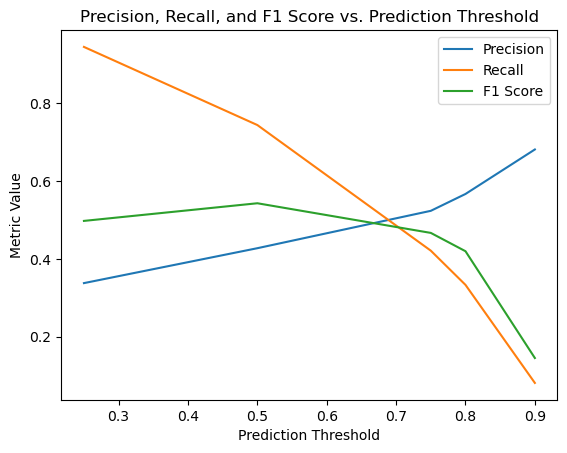

In [13]:
plt.plot(thr_values, [metric_dict[thr]["precision"] for thr in thr_values], label="Precision")
plt.plot(thr_values, [metric_dict[thr]["recall"] for thr in thr_values], label="Recall")
plt.plot(thr_values, [metric_dict[thr]["f1"] for thr in thr_values], label="F1 Score")
plt.xlabel("Prediction Threshold")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Prediction Threshold")
plt.legend()

In [35]:
weights_dict = {}
weights_list = [1,2,4,10,20]
for weight in weights_list:
    _, _, _, metrics = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=weight, return_scores=True, verbose=False, prediction_threshold=0.75)
    weights_dict[weight] = metrics

Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5


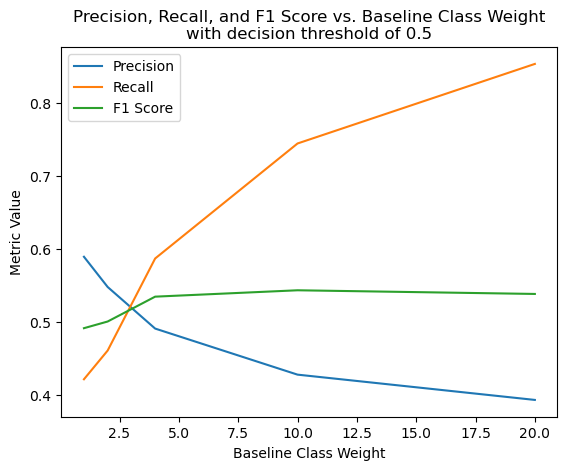

In [33]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.5")
plt.legend()

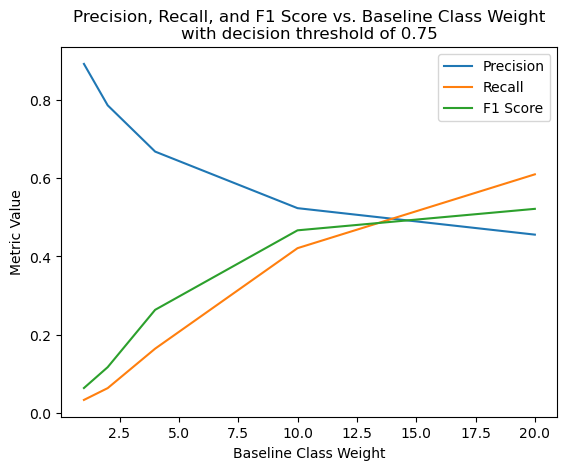

In [36]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.75")
plt.legend()

In [38]:
model, _,_  = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights="auto", return_scores=False, verbose=False)

In [ ]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=0.75)

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.638
Recall: 0.185
F1 Score: 0.287


In [5]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="test", prediction_threshold=0.5)

Predicting on test set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.524
Recall: 0.738
F1 Score: 0.613


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
model.classes_

array([0, 1])

In [ ]:
def plot_confusion_matrix(y, y_pred, normalise=False, title="", labels = ["non-baseline", "baseline"]):

    if normalise:
        normalise = "all"
    else:
        normalise = None
        
    cm = confusion_matrix(y, y_pred, labels=np.unique(y), normalize=normalise)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["non-baseline", "baseline"])
    # change ax labels to "Predicted label" and "Intem label "

    
    disp.plot(cmap=plt.cm.Blues)

    disp.ax_.set_title(title)
    disp.ax_.set(xlabel='Predicted label', ylabel='InTEM label')


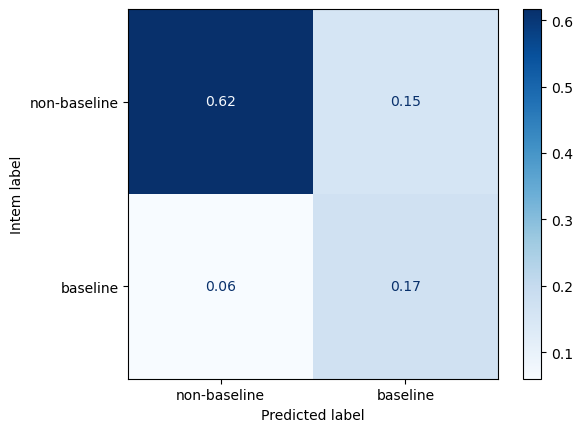

In [40]:
plot_confusion_matrix(y, y_pred, normalise=True)

In [43]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="full", prediction_threshold=0.5)

Predicting on full set for site: MHD with prediction threshold: 0.5
Loading data for site: MHD, period: 2016-2023
Precision: 0.573
Recall: 0.843
F1 Score: 0.683


In [44]:
site = "MHD"
species = "ch4".lower() #"hfc-134a" 
start_year=2016
end_year=2023

In [45]:
df_agage = read_agage(site, species, start_year=start_year, end_year=end_year)

In [46]:
import pandas as pd

In [71]:
def align_predictions_and_obs(y, y_pred, df_obs):
    """
    Align predictions with observed data, using the indeces of both timeseries.

    Parameters:
    - y: The true labels (observed baselines) as a pandas Series with a datetime index.
    - y_pred: The predicted labels (predicted baselines) pandas Series with a datetime index.
    - df_obs: A DataFrame containing the observed molefractions in a column named "mf" with a datetime index. Use read_agage to read in the observed data.

    Returns:
    - labelled_df: A DataFrame containing the observed molefractions, true baseline labels, and predicted baseline labels, all aligned by their datetime index.
    """

    y = y[(y.index.year >= min(df_obs.index.year)) & (y.index.year <= max(df_obs.index.year))]
    labelled_df = pd.merge_asof(pd.DataFrame({"baseline": y}), df_obs["mf"], left_index=True, right_index=True, direction='nearest')
    labelled_df = labelled_df[["mf", "baseline"]]
    labelled_df["predicted_baseline"] = y_pred
    return labelled_df


In [ ]:
labelled_df = align_predictions_and_obs(y, y_pred, df_agage)

In [1]:
class BaselineLabelledObservations:
    def __init__(self, y, y_pred, df_obs, site, species):
        self.site = site
        self.species = species
        self.labelled_df = align_predictions_and_obs(y, y_pred, df_obs)
        
    def plot_confusion_matrix(self, normalise=True, title="Confusion Matrix"):
        plot_confusion_matrix(self.labelled_df["baseline"], self.labelled_df["predicted_baseline"], normalise=normalise, title=title)
        
    def plot_obs(self, title=None):
        if title is None:
            title = f"MF of {self.species.upper()} at {self.site} with InTEM baseline Predictions"
        plot_obs(self.labelled_df, title=title)

    def plot_obs_with_labels(self, title=None, plot_true_negatives=True):
        if title is None:
            title = f"MF of {self.species.upper()} at {self.site} with baseline and model Predictions"
        plot_obs_and_labels(self.labelled_df, title=title, site=self.site, plot_true_negatives=plot_true_negatives)

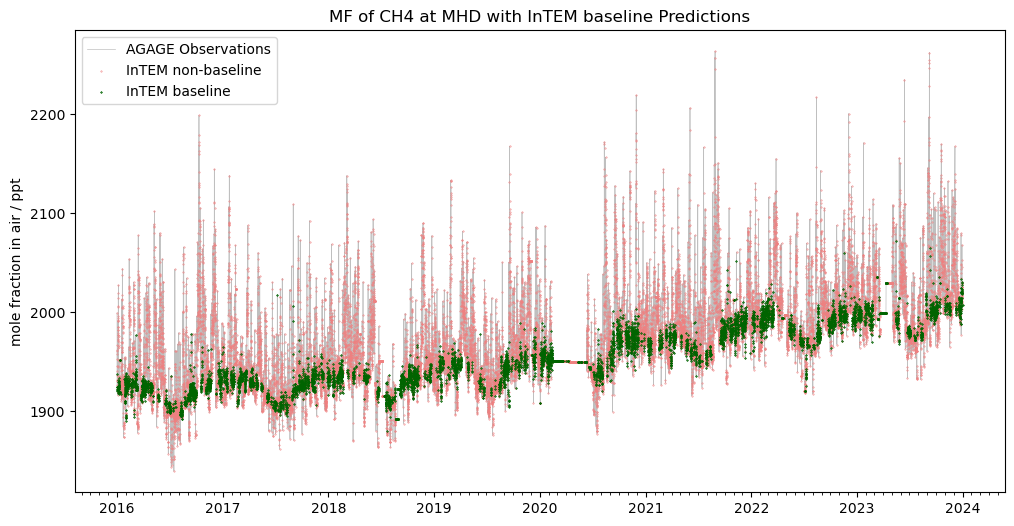

In [182]:
labelled_obs = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site)
labelled_obs.plot_obs()  

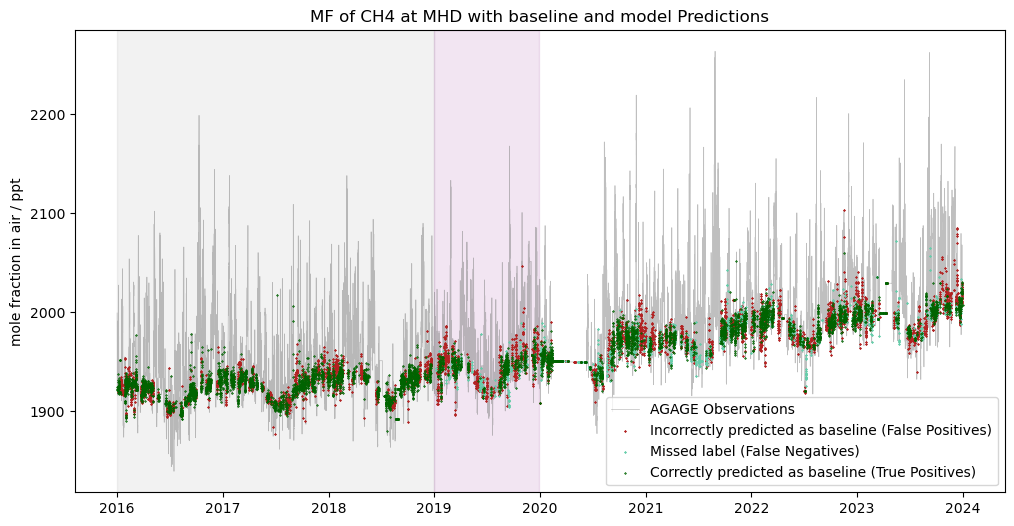

In [183]:
labelled_obs.plot_obs_with_labels(plot_true_negatives=False)

In [48]:
import numpy as np

In [77]:
cfg.training_period[site][0]

2016

In [96]:
import matplotlib.dates as mdates

In [196]:
def plot_obs(labelled_df, labels_from="InTEM", title=""):
    """
    Plot observed molefractions.

    Parameters:
    - labelled_df: A DataFrame containing the observed molefractions in a column named "mf", true baseline labels in a column named "baseline", and predicted baseline labels in a column named "predicted_baseline". The DataFrame should have a datetime index.
    - labels_from: The source of the labels to plot (e.g., "InTEM").
    - site: The site for which to plot observed molefractions.

    Returns:
    - A plot showing the observed molefractions and highlighting false positives, false negatives, and true positives.
    """
    if labels_from == "InTEM":
        true_mask = (labelled_df.baseline == 1)
        false_mask = (labelled_df.baseline == 0)
    elif labels_from == "model":
        true_mask = (labelled_df.predicted_baseline == 1)
        false_mask = (labelled_df.predicted_baseline == 0)
    else:
        raise ValueError("Invalid value for 'labels_from'. Please choose 'InTEM' or 'model'.")

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(labelled_df.index, labelled_df.mf, c="gray", label="AGAGE Observations", zorder=1, lw=0.5, alpha=0.5)

    ax.scatter(labelled_df.index[false_mask], labelled_df.mf[false_mask], color="lightcoral", label=f"{labels_from} non-baseline", zorder=5, s=0.5, alpha=0.5, marker='x')
    ax.scatter(labelled_df.index[true_mask], labelled_df.mf[true_mask], color="darkgreen", label=f"{labels_from} baseline", zorder=5, s=0.5, marker='x', alpha=0.8)

    # make markers bigger in the legend
    ax.legend(markerscale=6)

    ax.set_ylabel("mole fraction in air / ppt")

    locator = mdates.MonthLocator()
    ax.xaxis.set_minor_locator(locator)
    ax.tick_params(axis='x', which='minor', length=2)

    ax.set_title(title)
    plt.show()

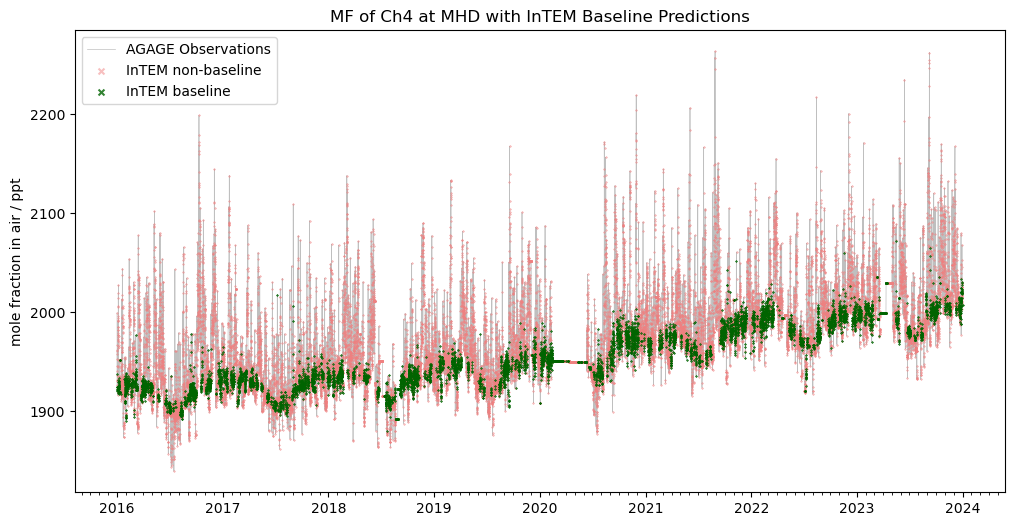

In [197]:
plot_obs(merged_df, title="MF of Ch4 at MHD with InTEM Baseline Predictions")

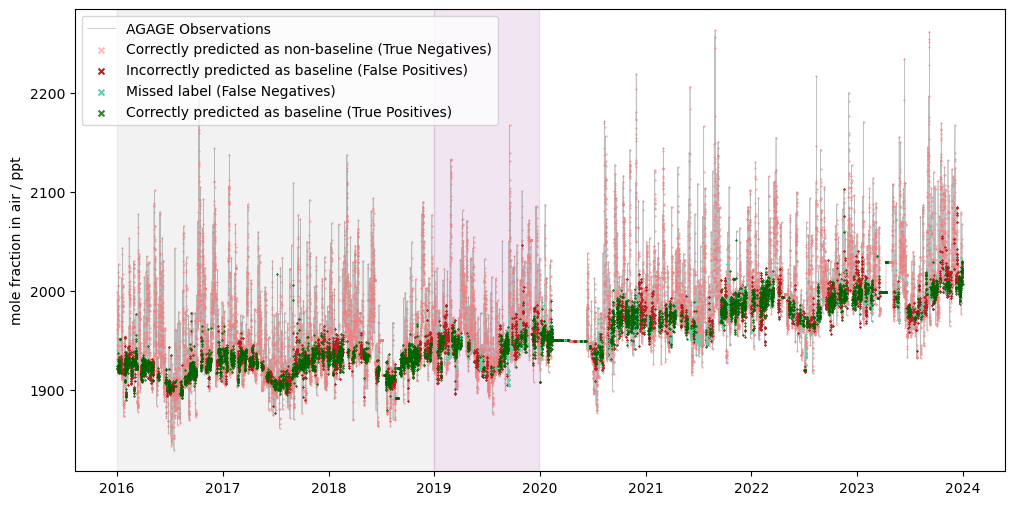

In [ ]:
plot_obs_with_labels(merged_df, site="MHD", plot_true_negatives=True  )

In [194]:
def plot_obs_and_labels(labelled_df, shade_train_and_val_periods=True, title="", site=None, plot_true_negatives=True):
    """
    Plot observed molefractions and predicted baseline labels over time.

    Parameters:
    - labelled_df: A DataFrame containing the observed molefractions in a column named "mf", true baseline labels in a column named "baseline", and predicted baseline labels in a column named "predicted_baseline". The DataFrame should have a datetime index.

    Returns:
    - A plot showing the observed molefractions and highlighting false positives, false negatives, and true positives.
    """

    true_positives_mask = (labelled_df.baseline == 1) & (labelled_df.predicted_baseline == 1)
    false_positives_mask = (labelled_df.baseline == 0) & (labelled_df.predicted_baseline == 1)
    false_negatives_mask = (labelled_df.baseline == 1) & (labelled_df.predicted_baseline == 0)
    true_negatives_mask = (labelled_df.baseline == 0) & (labelled_df.predicted_baseline == 0)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(labelled_df.index, labelled_df.mf, c="gray", label="AGAGE Observations", zorder=1, lw=0.5, alpha=0.5)

    if plot_true_negatives:
        ax.scatter(labelled_df.index[true_negatives_mask], labelled_df.mf[true_negatives_mask], color="lightcoral", label="Correctly predicted as non-baseline (True Negatives)", zorder=5, s=0.5, alpha=0.5, marker='x')

    ax.scatter(labelled_df.index[false_positives_mask], labelled_df.mf[false_positives_mask], color="firebrick", label="Incorrectly predicted as baseline (False Positives)", zorder=5, s=0.5, marker='x')
    ax.scatter(labelled_df.index[false_negatives_mask], labelled_df.mf[false_negatives_mask], color="mediumaquamarine", label="Missed label (False Negatives)", zorder=5, s=0.5, marker='x', alpha=1)
    ax.scatter(labelled_df.index[true_positives_mask], labelled_df.mf[true_positives_mask], color="darkgreen", label="Correctly predicted as baseline (True Positives)", zorder=5, s=0.5, marker='x', alpha=0.8)

    ax.legend(markerscale=6)

    ax.set_ylabel("mole fraction in air / ppt")

    locator = mdates.MonthLocator() 
    #ax.set_minor_locator(locator)

    # set montly tick labels on x axis

    if shade_train_and_val_periods:
        if site is not None:
            ax.axvspan(pd.to_datetime(f"{cfg.training_period[site][0]}-01-01"), pd.to_datetime(f"{cfg.training_period[site][1]}-12-31"), alpha=0.1, label="Training Set", color='grey', zorder=0)
            ax.axvspan(pd.to_datetime(f"{cfg.validation_period[site][0]}-01-01"), pd.to_datetime(f"{cfg.validation_period[site][1]}-12-31"), alpha=0.1, label="Validation Set", color='purple', zorder=0)
        else:
            print("Could not shade training and validation periods because site is None. Please provide a site name to shade these periods.")
    
    ax.set_title(title)

    plt.show()